# EDA корпусов -- MNIST и Fashion-MNIST

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

Два основных корпуса из темы 24 -- **MNIST** и **Fashion-MNIST**. 

Формат у них одинаковый, поэтому удобно сравнивать архитектуры без лишних различий в preprocessing.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from torchvision.datasets import FashionMNIST, MNIST


SEED = 143
CACHE_DIR = Path.home() / ".cache" / "mlstart_hw03"

cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks" and cwd.parent.name == "hws":
    HWS_DIR = cwd.parent
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")


In [2]:
mnist_train = MNIST(CACHE_DIR, train=True, download=True)
mnist_test = MNIST(CACHE_DIR, train=False, download=True)
fashion_train = FashionMNIST(CACHE_DIR, train=True, download=True)
fashion_test = FashionMNIST(CACHE_DIR, train=False, download=True)

mnist_X = mnist_train.data.numpy()
mnist_y = mnist_train.targets.numpy()
fashion_X = fashion_train.data.numpy()
fashion_y = fashion_train.targets.numpy()


## Общая информация

Оба датасета имеют одинаковый технический формат: 60 000 train + 10 000 test grayscale-изображений `28 × 28`, 10 классов, пиксели `uint8` в диапазоне `[0, 255]`.


In [3]:
def dataset_info(name, train, test):
    return {
        "dataset": name,
        "train_size": len(train),
        "test_size": len(test),
        "shape": tuple(train.data.shape[1:]),
        "dtype": str(train.data.dtype),
        "min_pixel": int(train.data.min()),
        "max_pixel": int(train.data.max()),
        "classes": len(train.classes),
    }

pd.DataFrame([
    dataset_info("MNIST", mnist_train, mnist_test),
    dataset_info("Fashion-MNIST", fashion_train, fashion_test),
])


,dataset,train_size,test_size,shape,dtype,min_pixel,max_pixel,classes
0,MNIST,60000,10000,"(28, 28)",torch.uint8,0,255,10
1,Fashion-MNIST,60000,10000,"(28, 28)",torch.uint8,0,255,10


Пропусков и категориальных признаков здесь нет.


## Баланс классов


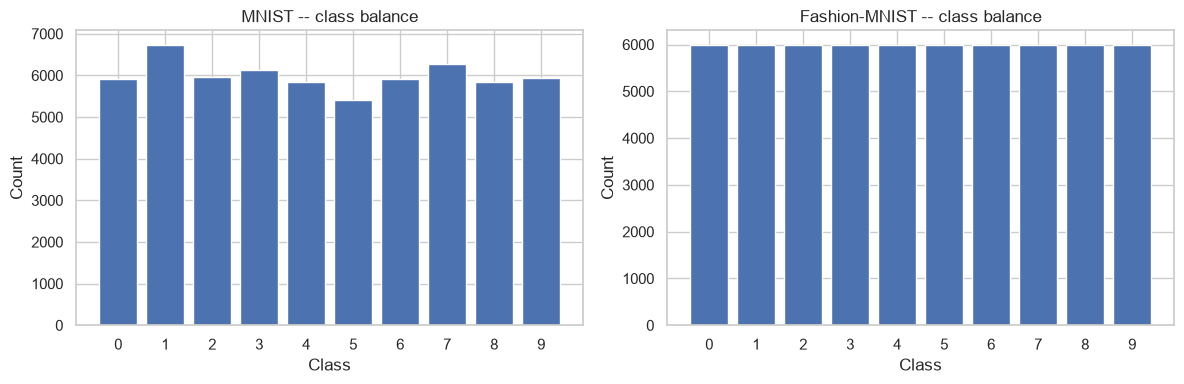

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y, name in [(axes[0], mnist_y, "MNIST"), (axes[1], fashion_y, "Fashion-MNIST")]:
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{name} -- class balance")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_class_balance.png", dpi=160, bbox_inches="tight")
plt.show()


Оба корпуса хорошо сбалансированы _(Fashion вообще почти идеально)_. Но дальше везде использую `balanced accuracy` как основную метрику.  
Дополнительно считаю `macro-F1`, `macro-precision` и `macro-recall`.


## Случайные объекты

Посмотреть, как выглядит корпус вообще. _Можно запускать по несколько раз и наблюдать новые примеры -- тут за воспроизводимостью не слежу_

In [20]:
def show_examples(X, y, classes, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(11, 5))
    indices = rng.choice(len(X), 10, replace=False)
    for ax, index in zip(axes.ravel(), indices):
        ax.imshow(X[index], cmap="gray")
        ax.set_title(classes[y[index]])
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


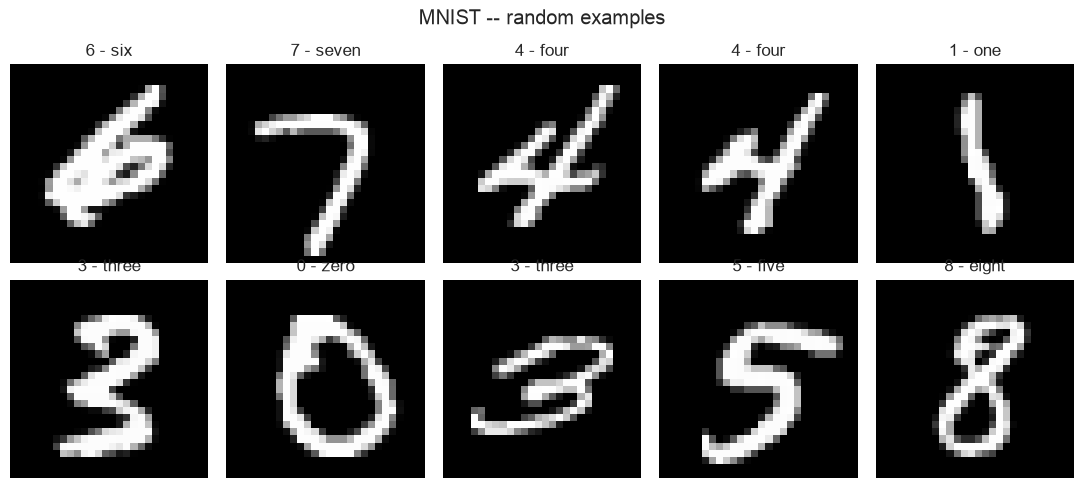

In [34]:
show_examples(mnist_X, mnist_y, mnist_train.classes, "MNIST -- random examples", "eda_mnist_examples.png")

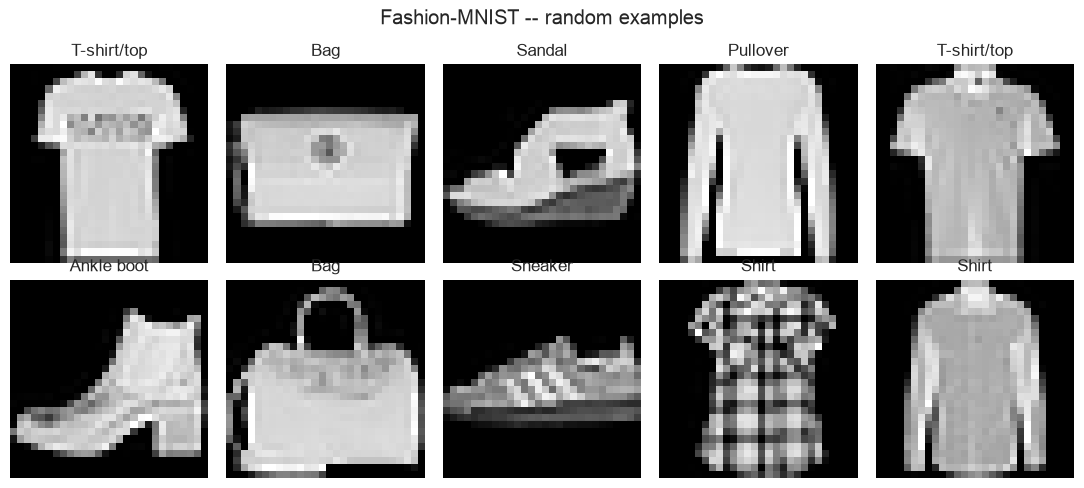

In [7]:
show_examples(fashion_X, fashion_y, fashion_train.classes, "Fashion-MNIST -- random examples", "eda_fashion_examples.png")


`MNIST` визуально проще: классы задаются формой цифры на черном фоне _(посмотрел состав корпуса -- выбросов каких-либо не увидел)_.

У `Fashion-MNIST` несколько классов реально похожи (`T-shirt/top`, `Shirt`, `Pullover`, `Coat`), так что ожидаю больше систематических ошибок именно между ними.


## Средний объект каждого класса


In [35]:
def plot_class_means(X, y, classes, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(11, 5))
    for cls, ax in enumerate(axes.ravel()):
        ax.imshow(X[y == cls].mean(axis=0), cmap="gray")
        ax.set_title(classes[cls])
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


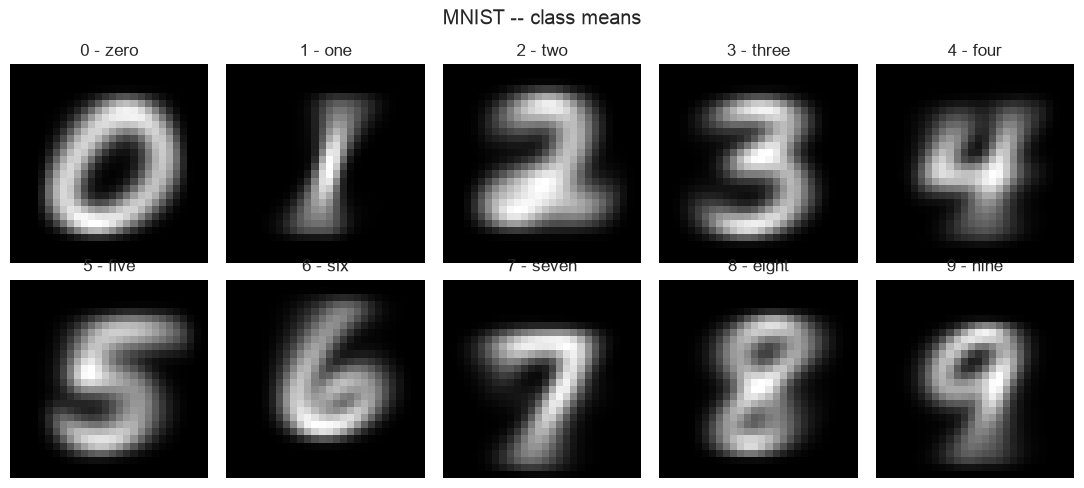

In [38]:
plot_class_means(mnist_X, mnist_y, mnist_train.classes, "MNIST -- class means", "eda_mnist_class_means.png")

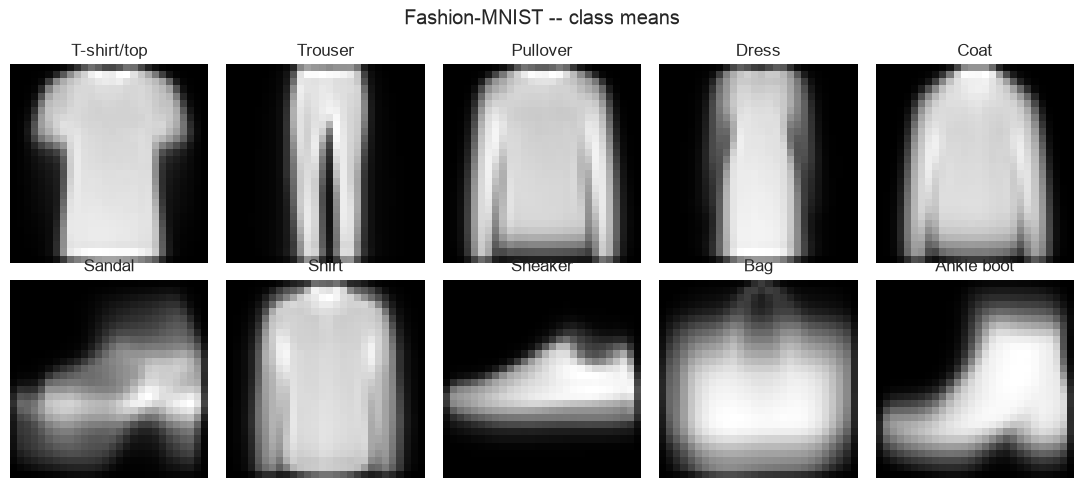

In [9]:
plot_class_means(fashion_X, fashion_y, fashion_train.classes, "Fashion-MNIST -- class means", "eda_fashion_class_means.png")


## Распределение интенсивности пикселей


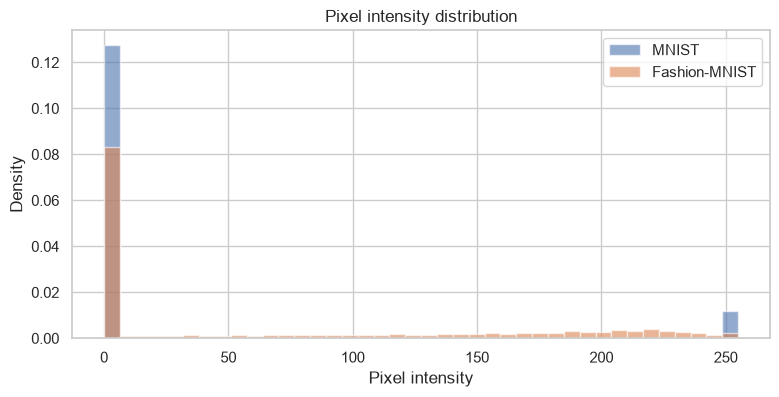

In [10]:
plt.figure(figsize=(9, 4))
plt.hist(mnist_X.ravel()[::50], bins=40, alpha=0.6, density=True, label="MNIST")
plt.hist(fashion_X.ravel()[::50], bins=40, alpha=0.6, density=True, label="Fashion-MNIST")
plt.xlabel("Pixel intensity")
plt.ylabel("Density")
plt.title("Pixel intensity distribution")
plt.legend()
plt.savefig(OUTPUT_DIR / "eda_pixel_hist.png", dpi=160, bbox_inches="tight")
plt.show()


У `MNIST` заметно больше фоновых нулей _(объясняется это тем, что само изображение -- меньше)_.   
`Fashion-MNIST` заполняет изображение плотнее, поэтому глобальные статистики изображения могут нести полезный сигнал для классических моделей.


## Feature engineering

Добавлю несколько дополнительных признаков, которые можно извлечь: `mean_brightness`, `pixel_std`, `ind_density`, `center_y`, `center_x`.

In [11]:
def engineered_features(X):
    X01 = X.astype(np.float32) / 255.0
    rows = np.arange(28, dtype=np.float32)[None, :, None]
    cols = np.arange(28, dtype=np.float32)[None, None, :]
    mass = X01.sum(axis=(1, 2)) + 1e-8

    return pd.DataFrame({
        "mean_brightness": X01.mean(axis=(1, 2)),
        "pixel_std": X01.std(axis=(1, 2)),
        "ink_density": (X01 > 0.2).mean(axis=(1, 2)),
        "center_y": (X01 * rows).sum(axis=(1, 2)) / mass / 27.0,
        "center_x": (X01 * cols).sum(axis=(1, 2)) / mass / 27.0,
    })

mnist_features = engineered_features(mnist_X)
fashion_features = engineered_features(fashion_X)
mnist_features.describe().T


,count,mean,std,min,25%,50%,75%,max
mean_brightness,60000.0,0.130660,0.043299,0.025440,0.099330,0.127386,0.157873,0.397574
pixel_std,60000.0,0.301312,0.047611,0.124900,0.268836,0.302826,0.334787,0.467293
ink_density,60000.0,0.161464,0.048299,0.034439,0.127551,0.159439,0.192602,0.433673
center_y,60000.0,0.518367,0.010711,0.499263,0.509072,0.518193,0.527630,0.537036
center_x,60000.0,0.518771,0.010774,0.499761,0.509400,0.518941,0.528129,0.537036


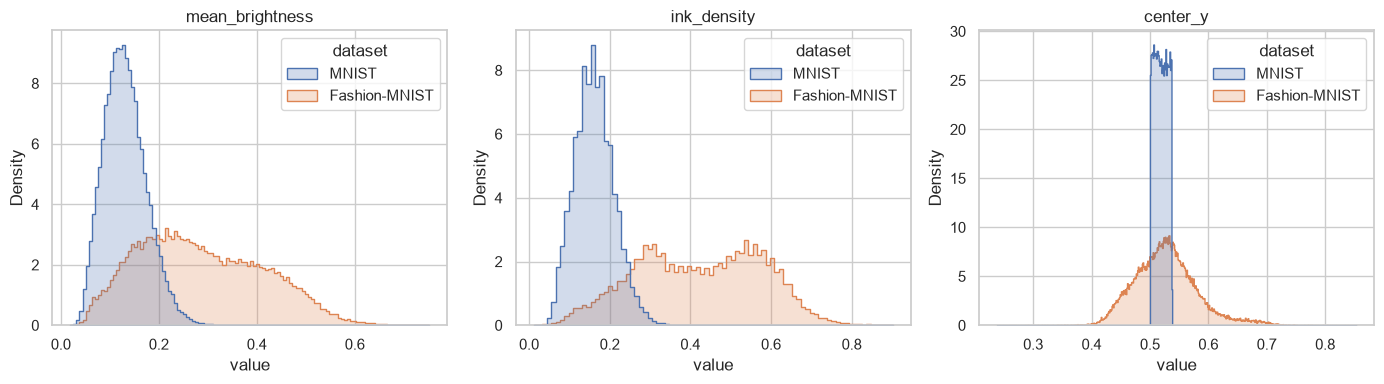

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, ["mean_brightness", "ink_density", "center_y"]):
    data = pd.DataFrame({
        "value": np.r_[mnist_features[feature], fashion_features[feature]],
        "dataset": ["MNIST"] * len(mnist_features) + ["Fashion-MNIST"] * len(fashion_features),
    })
    sns.histplot(data=data, x="value", hue="dataset", stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_engineered_features.png", dpi=160, bbox_inches="tight")
plt.show()


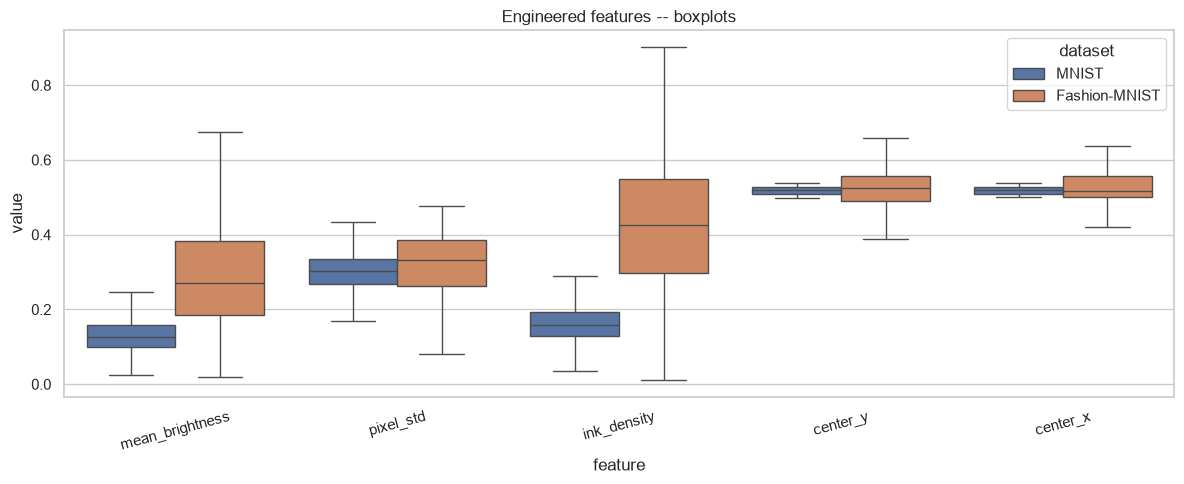

In [13]:
box_data = pd.concat([
    mnist_features.assign(dataset="MNIST"),
    fashion_features.assign(dataset="Fashion-MNIST"),
], ignore_index=True).melt(id_vars="dataset", var_name="feature", value_name="value")

plt.figure(figsize=(12, 5))
sns.boxplot(data=box_data, x="feature", y="value", hue="dataset", showfliers=False)
plt.title("Engineered features -- boxplots")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_engineered_features_boxplot.png", dpi=160, bbox_inches="tight")
plt.show()


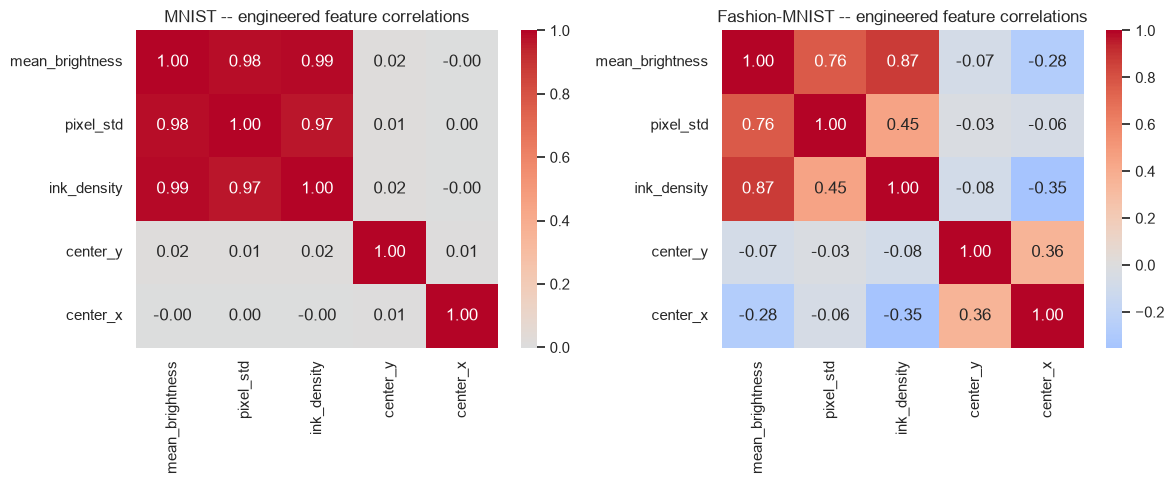

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, features, name in [
    (axes[0], mnist_features, "MNIST"),
    (axes[1], fashion_features, "Fashion-MNIST"),
]:
    sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title(f"{name} -- engineered feature correlations")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_engineered_features_correlations.png", dpi=160, bbox_inches="tight")
plt.show()


Видны некоторые корреляции между новыми признаками, и это нормально из-за их физического смысла _(см. ниже)_. Есть и некоррелирующие, мб моделям получится извлечь из них что-то полезное. В классическом ноутбуке добавляю их к 784 пикселям:

- `mean_brightness` -- общая заполненность изображения;
- `pixel_std` -- насколько контрастно распределены пиксели;
- `ink_density` -- доля заметно ненулевых пикселей;
- `center_x`, `center_y` -- центр массы изображения.

Для MLP их отдельно не добавляю: сеть и так получает все пиксели, а задача 24 должна в первую очередь измерять эффект архитектуры.


## Где в изображении находится сигнал


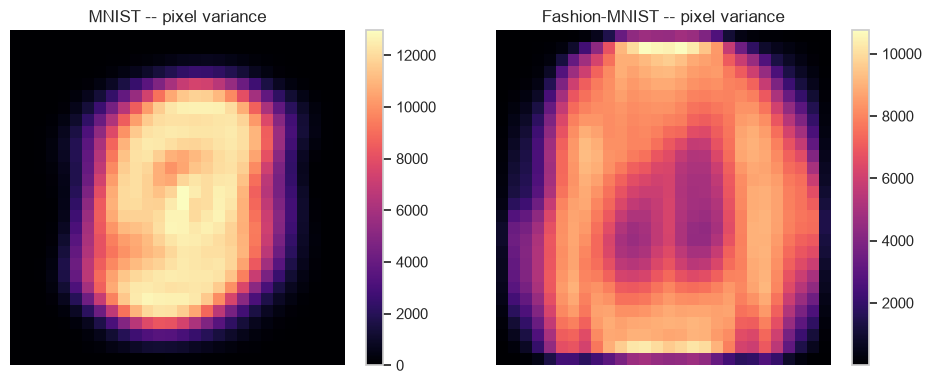

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, X, name in [(axes[0], mnist_X, "MNIST"), (axes[1], fashion_X, "Fashion-MNIST")]:
    variance_map = X.astype(np.float32).var(axis=0)
    im = ax.imshow(variance_map, cmap="magma")
    ax.set_title(f"{name} -- pixel variance")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_pixel_variance.png", dpi=160, bbox_inches="tight")
plt.show()


В обоих датасетах информативна в основном центральная область. Крайние пиксели вручную не выкидываю: тогда мы бы уже меняли представление и смешивали эффект feature selection с эффектом depth/width.


## Похожесть классов по средним изображениям


In [39]:
def centroid_distance_plot(X, y, classes, title, filename):
    centroids = np.stack([X[y == cls].mean(axis=0).ravel() for cls in range(10)])
    distances = pairwise_distances(centroids)
    plt.figure(figsize=(9, 7))
    sns.heatmap(distances, xticklabels=classes, yticklabels=classes, cmap="viridis")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


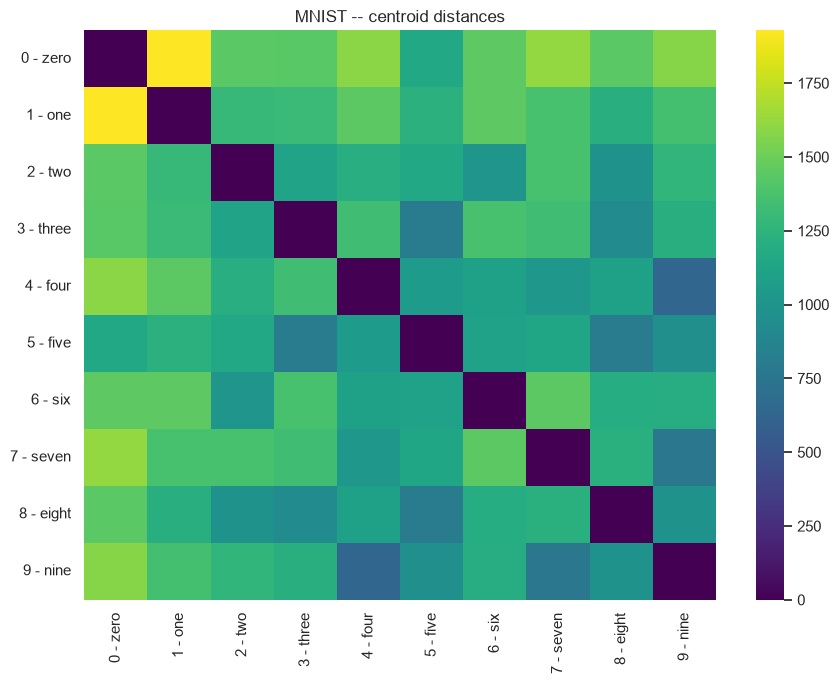

In [40]:
centroid_distance_plot(mnist_X, mnist_y, mnist_train.classes, "MNIST -- centroid distances", "eda_mnist_centroid_distances.png")

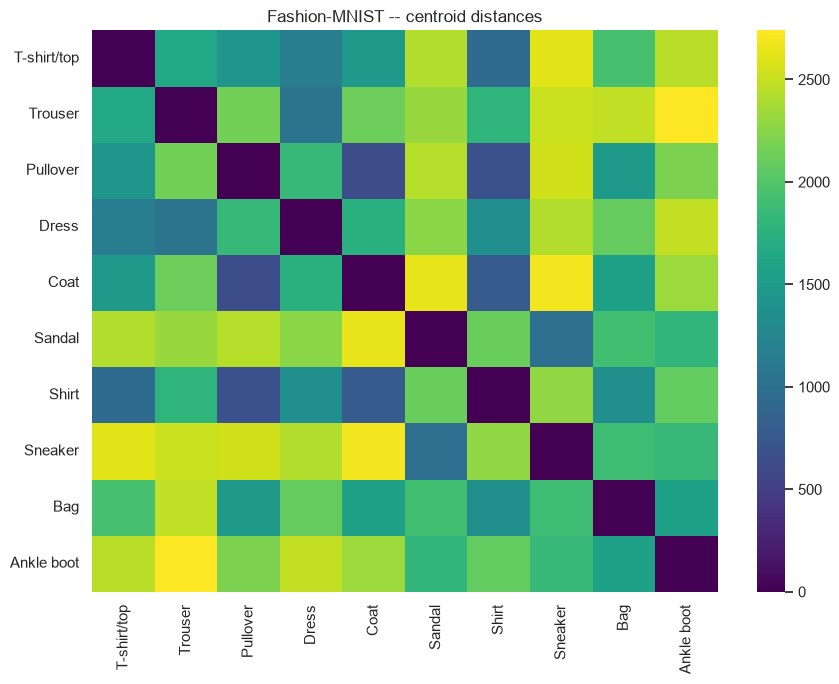

In [17]:
centroid_distance_plot(fashion_X, fashion_y, fashion_train.classes, "Fashion-MNIST -- centroid distances", "eda_fashion_centroid_distances.png")


Опять же, в `Fashion`-корпусе есть довольно схожие между собой классы, в то время как у чисел такая зависимость менее выражена.

## PCA-проекция


In [41]:
def plot_pca(X, y, title, filename):
    sample_idx = rng.choice(len(X), 5000, replace=False)
    X_sample = X[sample_idx].reshape(len(sample_idx), -1).astype(np.float32) / 255.0
    y_sample = y[sample_idx]
    projection = PCA(n_components=2, random_state=SEED).fit_transform(X_sample)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(projection[:, 0], projection[:, 1], c=y_sample, s=5, alpha=0.5, cmap="tab10")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, ticks=range(10))
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()



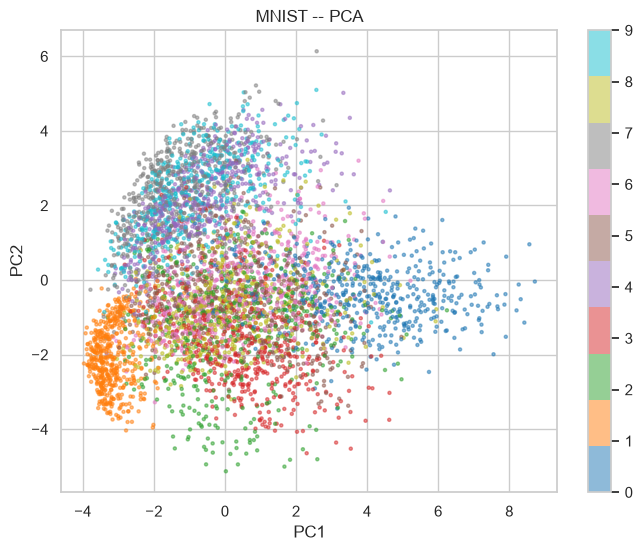

In [42]:
plot_pca(mnist_X, mnist_y, "MNIST -- PCA", "eda_mnist_pca.png")

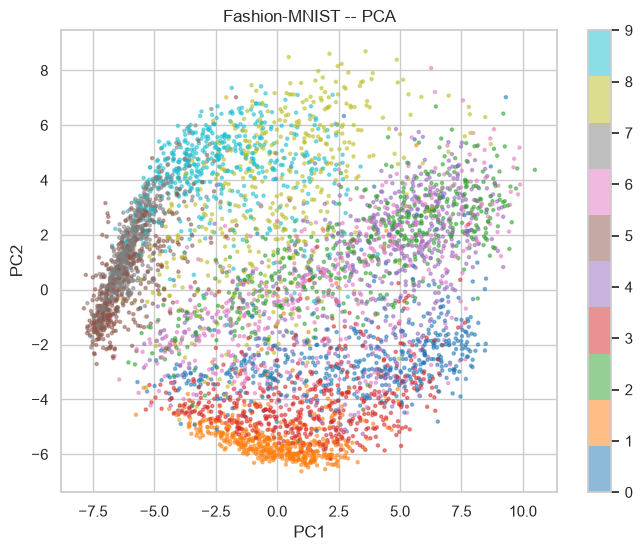

In [19]:
plot_pca(fashion_X, fashion_y, "Fashion-MNIST -- PCA", "eda_fashion_pca.png")


`Fashion` чуть более разделим, хотя все равно не панацея.

## Выводы

- `MNIST` и `Fashion-MNIST` имеют одинаковый размер входа и число классов -- хороший контролируемый набор для исследования архитектуры, выбор корпусов одобряю.
- Основная метрика дальше -- `balanced accuracy`; дополнительно `macro-F1`, `macro-precision`, `macro-recall`.
- Пропусков и категориальных признаков нет; странные редкие изображения не удаляю как «выбросы».
- По средним образам и PCA видно, что главная зона риска Fashion-MNIST -- похожие виды верхней одежды. Это потом отдельно проверю по confusion matrix.
